---
*IIT Short Course - Python Programming Lectures*  
*Instructor: Md Mostafizur Rahaman*  
*Email: bsse1320@iit.du.ac.bd* 


# Lecture 13: Row Operations and Handling Missing Values

Dataset: sample_data.csv - Contains employee data for research/IT/education organization

## Install Pandas (Only Once)

In [139]:
!pip install pandas
# !python -m pip install pandas # This is an alternative way to install pandas using the Python module flag.

## Import Required Libraries

Import the necessary libraries, including Pandas.

In [140]:
import pandas as pd

## Load Data from CSV

Load data from a CSV file into a Pandas DataFrame.

In [141]:
df = pd.read_csv('sample_data.csv')
df.head()

,employee_id,name,department,position,salary,years_experience,hire_date,performance_score,has_certification
0,101,Ayesha Khan,IT,Software Engineer,85000,5,2019-01-15,4.5,True
1,102,Rashed Ahmed,NaN,HR Manager,72000,8,2016-03-22,4.2,True
2,103,Fatima Begum,Research,Research Analyst,68000,3,2021-06-10,4.7,False
3,104,Karim Hassan,IT,Data Scientist,95000,6,2018-09-05,4.8,True
4,105,Nasima Akter,Education,Senior Lecturer,75000,12,2012-01-20,4.4,True


## Handle Data Types

Check and convert data types, such as converting hire_date to datetime.

In [142]:
column_data_types = df.dtypes
print(f"Data types of all columns:\n{column_data_types}")

Data types of all columns:
employee_id            int64
name                     str
department               str
position                 str
salary                 int64
years_experience       int64
hire_date                str
performance_score    float64
has_certification       bool
dtype: object


In [143]:
salary_dtype = df['salary'].dtype
hire_date_original_dtype = df['hire_date'].dtype
print(f"\n\n>> Salary data type: {salary_dtype}, Hire date original type: {hire_date_original_dtype}")



>> Salary data type: int64, Hire date original type: str


In [144]:
df['hire_date'] = pd.to_datetime(df['hire_date'])
hire_date_converted_dtype = df['hire_date'].dtype
print(f"\n\n>> Hire date after conversion: {hire_date_converted_dtype}")



>> Hire date after conversion: datetime64[us]


## 1. Row Operations

This section covers various row operations including 
- Preparing datasets
- Selecting rows by index or conditions
- Adding new rows
- Deleting rows, and 
- Updating row values.

### Preparing Datasets

Before performing row operations, ensure your dataset is loaded and cleaned. We'll use the sample_data.csv dataset loaded earlier.

In [145]:
# Display the first few rows to prepare for operations
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,employee_id,name,department,position,salary,years_experience,hire_date,performance_score,has_certification
0,101,Ayesha Khan,IT,Software Engineer,85000,5,2019-01-15,4.5,True
1,102,Rashed Ahmed,NaN,HR Manager,72000,8,2016-03-22,4.2,True
2,103,Fatima Begum,Research,Research Analyst,68000,3,2021-06-10,4.7,False
3,104,Karim Hassan,IT,Data Scientist,95000,6,2018-09-05,4.8,True
4,105,Nasima Akter,Education,Senior Lecturer,75000,12,2012-01-20,4.4,True


### Selecting Row by Index

You can select specific rows using their index position with .iloc[] or by label with .loc[].

In [146]:
# Select a single row by index (e.g., first row)
first_row = df.iloc[0]
print("First row:")
print(first_row)

# Select multiple rows by index (e.g., rows 1 to 3)
rows_1_to_3 = df.iloc[1:4]
print("\nRows 1 to 3:")
print(rows_1_to_3)

First row:
employee_id                          101
name                         Ayesha Khan
department                            IT
position               Software Engineer
salary                             85000
years_experience                       5
hire_date            2019-01-15 00:00:00
performance_score                    4.5
has_certification                   True
Name: 0, dtype: object

Rows 1 to 3:
   employee_id          name department          position  salary  \
1          102  Rashed Ahmed        NaN        HR Manager   72000   
2          103  Fatima Begum   Research  Research Analyst   68000   
3          104  Karim Hassan         IT    Data Scientist   95000   

   years_experience  hire_date  performance_score  has_certification  
1                 8 2016-03-22                4.2               True  
2                 3 2021-06-10                4.7              False  
3                 6 2018-09-05                4.8               True  


### Selecting Row by Conditions

Select rows that meet specific conditions using boolean indexing.

In [147]:
# Select rows where salary > 70000
high_salary_rows = df[df['salary'] > 70000]
print("Rows with salary > 70000:")
print(high_salary_rows[['name', 'salary']])

# Select rows where department is 'IT' and years_experience > 3
it_experienced = df[(df['department'] == 'IT') & (df['years_experience'] > 3)]
print("\nIT employees with > 3 years experience:")
print(it_experienced[['name', 'department', 'years_experience', 'salary']])

Rows with salary > 70000:
                name  salary
0        Ayesha Khan   85000
1       Rashed Ahmed   72000
3       Karim Hassan   95000
4       Nasima Akter   75000
6      Shafia Rahman  110000
8      Amina Sultana   92000
11     Samir Hossain   98000
14  Rumana Chowdhury  105000

IT employees with > 3 years experience:
                name department  years_experience  salary
0        Ayesha Khan         IT                 5   85000
3       Karim Hassan         IT                 6   95000
8      Amina Sultana         IT                 7   92000
11     Samir Hossain         IT                 9   98000
14  Rumana Chowdhury         IT                11  105000


### Adding New Row

Add a new row to the DataFrame using pd.concat() or .loc[].

In [148]:
df.loc[len(df)] = [199,"Rakib", "IIT", "Manager", 100000, 2, "2026-09-23", 4.9, True]
print(df.tail())

    employee_id              name department             position  salary  \
11          112     Samir Hossain         IT            Tech Lead   98000   
12          113     Fatema Yousuf  Education   Course Coordinator   58000   
13          114        Rafiq Khan   Research  Post-Doc Researcher   70000   
14          115  Rumana Chowdhury         IT   Software Architect  105000   
15          199             Rakib        IIT              Manager  100000   

    years_experience            hire_date  performance_score  \
11                 9  2015-10-08 00:00:00                4.7   
12                 2  2022-09-18 00:00:00                3.8   
13                 2  2022-01-25 00:00:00                4.5   
14                11  2013-03-01 00:00:00                4.8   
15                 2           2026-09-23                4.9   

    has_certification  
11               True  
12              False  
13              False  
14               True  
15               True  


In [149]:
df.loc[18:] = [299,"Rakib", "IIT", "Manager", 100000, 2, "2026-09-23", 4.9, True]
print(df.tail())
df

    employee_id              name department             position  salary  \
11          112     Samir Hossain         IT            Tech Lead   98000   
12          113     Fatema Yousuf  Education   Course Coordinator   58000   
13          114        Rafiq Khan   Research  Post-Doc Researcher   70000   
14          115  Rumana Chowdhury         IT   Software Architect  105000   
15          199             Rakib        IIT              Manager  100000   

    years_experience            hire_date  performance_score  \
11                 9  2015-10-08 00:00:00                4.7   
12                 2  2022-09-18 00:00:00                3.8   
13                 2  2022-01-25 00:00:00                4.5   
14                11  2013-03-01 00:00:00                4.8   
15                 2           2026-09-23                4.9   

    has_certification  
11               True  
12              False  
13              False  
14               True  
15               True  


,employee_id,name,department,position,salary,years_experience,hire_date,performance_score,has_certification
0,101,Ayesha Khan,IT,Software Engineer,85000,5,2019-01-15 00:00:00,4.5,True
1,102,Rashed Ahmed,NaN,HR Manager,72000,8,2016-03-22 00:00:00,4.2,True
2,103,Fatima Begum,Research,Research Analyst,68000,3,2021-06-10 00:00:00,4.7,False
3,104,Karim Hassan,IT,Data Scientist,95000,6,2018-09-05 00:00:00,4.8,True
4,105,Nasima Akter,Education,Senior Lecturer,75000,12,2012-01-20 00:00:00,4.4,True
5,106,Fahim Hossain,IT,IT Support,55000,2,2022-11-01 00:00:00,3.9,False
6,107,Shafia Rahman,Research,Principal Investigator,110000,15,2008-04-15 00:00:00,4.9,True
7,108,Tarek Mahmud,Education,Assistant Professor,65000,4,2020-08-30 00:00:00,4.3,False
8,109,Amina Sultana,IT,DevOps Engineer,92000,7,2017-05-12 00:00:00,4.6,True
9,110,Arifur Rahman,HR,Recruiter,65000,3,2021-02-14 00:00:00,4.0,False


In [150]:
# Add a new row using pd.concat()
new_row = pd.DataFrame({
    'name': ['John Doe'], # multiple rows can be added by providing more values in the lists
    'department': ['HR'],
    'position': ['Manager'],
    'salary': [75000],
    'years_experience': [8],
    'hire_date': ['2023-05-15'],
    'has_certification': [True]
})
df = pd.concat([df, new_row], ignore_index=True)
print("DataFrame after adding new row:")
print(df.tail())  # Show last few rows

DataFrame after adding new row:
    employee_id              name department             position  salary  \
12        113.0     Fatema Yousuf  Education   Course Coordinator   58000   
13        114.0        Rafiq Khan   Research  Post-Doc Researcher   70000   
14        115.0  Rumana Chowdhury         IT   Software Architect  105000   
15        199.0             Rakib        IIT              Manager  100000   
16          NaN          John Doe         HR              Manager   75000   

    years_experience            hire_date  performance_score  \
12                 2  2022-09-18 00:00:00                3.8   
13                 2  2022-01-25 00:00:00                4.5   
14                11  2013-03-01 00:00:00                4.8   
15                 2           2026-09-23                4.9   
16                 8           2023-05-15                NaN   

    has_certification  
12              False  
13              False  
14               True  
15               True  


### Deleting a Row

Remove a row from the DataFrame using .drop().

In [151]:
# Delete the last row (the one we just added)
df = df.drop(df.index[-1])
print("DataFrame after deleting the last row:")
print(df.tail())  # Show last few rows

DataFrame after deleting the last row:
    employee_id              name department             position  salary  \
11        112.0     Samir Hossain         IT            Tech Lead   98000   
12        113.0     Fatema Yousuf  Education   Course Coordinator   58000   
13        114.0        Rafiq Khan   Research  Post-Doc Researcher   70000   
14        115.0  Rumana Chowdhury         IT   Software Architect  105000   
15        199.0             Rakib        IIT              Manager  100000   

    years_experience            hire_date  performance_score  \
11                 9  2015-10-08 00:00:00                4.7   
12                 2  2022-09-18 00:00:00                3.8   
13                 2  2022-01-25 00:00:00                4.5   
14                11  2013-03-01 00:00:00                4.8   
15                 2           2026-09-23                4.9   

    has_certification  
11               True  
12              False  
13              False  
14               

### Updating a Row Value

Update specific values in a row using .loc[] or .iloc[].

In [152]:
# Update the salary of the first row
df.loc[0, 'salary'] = 95000
print("DataFrame after updating first row's salary:")
print(df.head(1))  # Show first row

DataFrame after updating first row's salary:
   employee_id         name department           position  salary  \
0        101.0  Ayesha Khan         IT  Software Engineer   95000   

   years_experience            hire_date  performance_score  has_certification  
0                 5  2019-01-15 00:00:00                4.5               True  


## 2. Handling Missing Values

This section covers detecting, dropping, and filling missing values in the dataset.

### Dropping Missing Values

Remove rows or columns with missing values using .dropna().

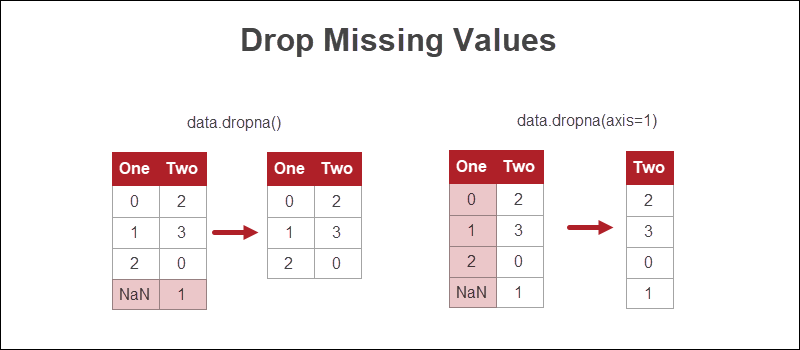

In [153]:
# Create a copy of the DataFrame to demonstrate dropping missing values
df_with_na = df.copy()

# Introduce some missing values for demonstration
df_with_na.loc[4, 'salary'] = None
df_with_na.loc[3, 'department'] = None

print("DataFrame with introduced missing values:")
print(df_with_na[['name', 'salary', 'department']].head(7))

DataFrame with introduced missing values:
            name    salary department
0    Ayesha Khan   95000.0         IT
1   Rashed Ahmed   72000.0        NaN
2   Fatima Begum   68000.0   Research
3   Karim Hassan   95000.0        NaN
4   Nasima Akter       NaN  Education
5  Fahim Hossain   55000.0         IT
6  Shafia Rahman  110000.0   Research


In [154]:
print(df_with_na.isnull())

    employee_id   name  department  position  salary  years_experience  \
0         False  False       False     False   False             False   
1         False  False        True     False   False             False   
2         False  False       False     False   False             False   
3         False  False        True     False   False             False   
4         False  False       False     False    True             False   
5         False  False       False     False   False             False   
6         False  False       False     False   False             False   
7         False  False       False     False   False             False   
8         False  False       False     False   False             False   
9         False  False       False     False   False             False   
10        False  False       False     False   False             False   
11        False  False       False     False   False             False   
12        False  False       False    

In [155]:
print(df_with_na.isnull().sum())

employee_id          0
name                 0
department           2
position             0
salary               1
years_experience     0
hire_date            0
performance_score    0
has_certification    0
dtype: int64


In [156]:
# Drop rows with any missing values
df_dropped = df_with_na.dropna()
print("\nDataFrame after dropping rows with missing values:")
print(df_dropped.head(3))


DataFrame after dropping rows with missing values:
   employee_id           name department           position   salary  \
0        101.0    Ayesha Khan         IT  Software Engineer  95000.0   
2        103.0   Fatima Begum   Research   Research Analyst  68000.0   
5        106.0  Fahim Hossain         IT         IT Support  55000.0   

   years_experience            hire_date  performance_score  has_certification  
0                 5  2019-01-15 00:00:00                4.5               True  
2                 3  2021-06-10 00:00:00                4.7              False  
5                 2  2022-11-01 00:00:00                3.9              False  


In [157]:
# Drop columns with any missing values
df_dropped_cols = df_with_na.dropna(axis=1)
print("\nDataFrame after dropping columns with missing values:")
print(df_dropped_cols.head(3))


DataFrame after dropping columns with missing values:
   employee_id          name           position  years_experience  \
0        101.0   Ayesha Khan  Software Engineer                 5   
1        102.0  Rashed Ahmed         HR Manager                 8   
2        103.0  Fatima Begum   Research Analyst                 3   

             hire_date  performance_score  has_certification  
0  2019-01-15 00:00:00                4.5               True  
1  2016-03-22 00:00:00                4.2               True  
2  2021-06-10 00:00:00                4.7              False  


### Filling Missing Values

Fill missing values with specific values, mean, median, etc., using .fillna().

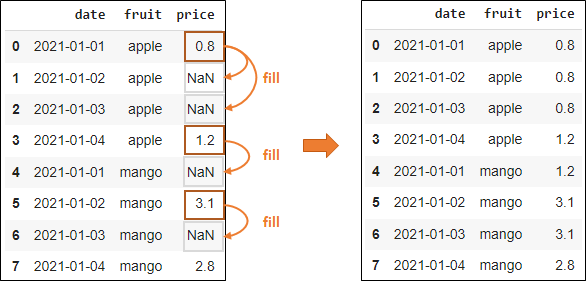

In [158]:
# Fill missing values with a specific value
df_filled = df_with_na.fillna({'salary': 0, 'department': 'Unknown'})
print("DataFrame after filling missing values with specific values:")
print(df_filled.head(3))

DataFrame after filling missing values with specific values:
   employee_id          name department           position   salary  \
0        101.0   Ayesha Khan         IT  Software Engineer  95000.0   
1        102.0  Rashed Ahmed    Unknown         HR Manager  72000.0   
2        103.0  Fatima Begum   Research   Research Analyst  68000.0   

   years_experience            hire_date  performance_score  has_certification  
0                 5  2019-01-15 00:00:00                4.5               True  
1                 8  2016-03-22 00:00:00                4.2               True  
2                 3  2021-06-10 00:00:00                4.7              False  


In [159]:
# Fill missing values with mean for numeric columns
df_filled_mean = df_with_na.copy()
df_filled_mean['salary'] = df_filled_mean['salary'].fillna(df_filled_mean['salary'].mean())
print("\nDataFrame after filling salary with mean:")
print(df_filled_mean.head(3))


DataFrame after filling salary with mean:
   employee_id          name department           position   salary  \
0        101.0   Ayesha Khan         IT  Software Engineer  95000.0   
1        102.0  Rashed Ahmed        NaN         HR Manager  72000.0   
2        103.0  Fatima Begum   Research   Research Analyst  68000.0   

   years_experience            hire_date  performance_score  has_certification  
0                 5  2019-01-15 00:00:00                4.5               True  
1                 8  2016-03-22 00:00:00                4.2               True  
2                 3  2021-06-10 00:00:00                4.7              False  


### Forward/Backward Fill

Use forward fill (ffill) or backward fill (bfill) to propagate non-null values.

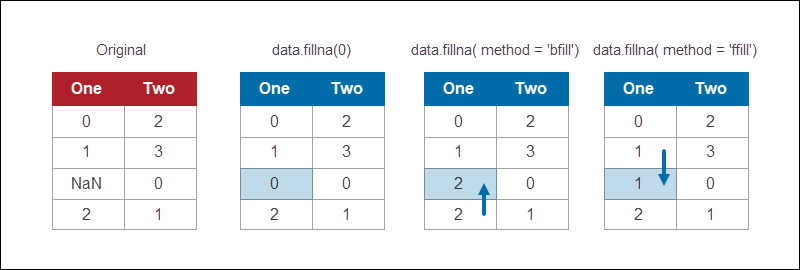

In [160]:
print(df_with_na[['name', 'salary', 'department']].head(5))

           name   salary department
0   Ayesha Khan  95000.0         IT
1  Rashed Ahmed  72000.0        NaN
2  Fatima Begum  68000.0   Research
3  Karim Hassan  95000.0        NaN
4  Nasima Akter      NaN  Education


In [161]:
# Forward fill: propagate last valid observation forward
df_ffill = df_with_na.ffill()
print("DataFrame after forward fill:")
print(df_ffill[['name', 'salary', 'department']].head(7))

DataFrame after forward fill:
            name    salary department
0    Ayesha Khan   95000.0         IT
1   Rashed Ahmed   72000.0         IT
2   Fatima Begum   68000.0   Research
3   Karim Hassan   95000.0   Research
4   Nasima Akter   95000.0  Education
5  Fahim Hossain   55000.0         IT
6  Shafia Rahman  110000.0   Research


In [162]:


# Backward fill: use next valid observation to fill gap
df_bfill = df_with_na.bfill()
print("\nDataFrame after backward fill:")
print(df_bfill[['name', 'salary', 'department']].head(7))


DataFrame after backward fill:
            name    salary department
0    Ayesha Khan   95000.0         IT
1   Rashed Ahmed   72000.0   Research
2   Fatima Begum   68000.0   Research
3   Karim Hassan   95000.0  Education
4   Nasima Akter   55000.0  Education
5  Fahim Hossain   55000.0         IT
6  Shafia Rahman  110000.0   Research


## BONUS: Sampling Methods to Query the Data

This section demonstrates how to query and sample data for specific insights, such as top employees by salary, experience, etc.

In [163]:
# Top 2 most paid employees
top_2_paid = df.nlargest(2, 'salary')[['name', 'salary']]
print("Top 2 most paid employees:")
print(top_2_paid)

Top 2 most paid employees:
                name  salary
6      Shafia Rahman  110000
14  Rumana Chowdhury  105000


In [164]:
# Top 5 most experienced employees
top_5_experienced = df.nlargest(5, 'years_experience')[['name', 'years_experience']]
print("\nTop 5 most experienced employees:")
print(top_5_experienced)


Top 5 most experienced employees:
                name  years_experience
6      Shafia Rahman                15
4       Nasima Akter                12
14  Rumana Chowdhury                11
11     Samir Hossain                 9
1       Rashed Ahmed                 8


In [165]:
# Which employee position earns the most salary (average)
avg_salary_by_position = df.groupby('position')['salary'].mean().sort_values(ascending=False)
print("\nAverage salary by position (highest first):")
print(avg_salary_by_position)


Average salary by position (highest first):
position
Principal Investigator    110000.0
Software Architect        105000.0
Manager                   100000.0
Tech Lead                  98000.0
Software Engineer          95000.0
Data Scientist             95000.0
DevOps Engineer            92000.0
Senior Lecturer            75000.0
HR Manager                 72000.0
Post-Doc Researcher        70000.0
Research Analyst           68000.0
Assistant Professor        65000.0
Recruiter                  65000.0
Course Coordinator         58000.0
IT Support                 55000.0
Research Assistant         45000.0
Name: salary, dtype: float64


In [167]:
# Top 5 newest employees (most recent hire dates)
df['hire_date'] = pd.to_datetime(df['hire_date'], errors='coerce')
top_5_new = df.sort_values('hire_date', ascending=False).head(5)[['name', 'hire_date']]
print("\nTop 5 newest employees:")
print(top_5_new)


Top 5 newest employees:
              name  hire_date
15           Rakib 2026-09-23
10  Marzina Akhter 2023-07-01
5    Fahim Hossain 2022-11-01
12   Fatema Yousuf 2022-09-18
13      Rafiq Khan 2022-01-25


### Simple Instructions for Answering Queries

To answer similar queries for any dataset, follow these steps:

1. **Identify the question**: What are you trying to find? (e.g., top N by a column, average by group)

2. **Choose the right method**:
   - For top N: Use `df.nlargest(N, 'column')` or `df.sort_values('column', ascending=False).head(N)`
   - For bottom N: Use `df.nsmallest(N, 'column')` or `df.sort_values('column').head(N)`
   - For averages by group: Use `df.groupby('group_column')['value_column'].mean()`
   - For counts: Use `df.groupby('group_column').size()` or `df['column'].value_counts()`

3. **Select relevant columns**: Use `[['col1', 'col2']]` to show only needed columns

4. **Sort if needed**: Add `.sort_values()` for ordering results

5. **Print results**: Use `print()` with descriptive messages

Example: To find the 3 oldest employees by hire date:
```python
oldest_3 = df.nsmallest(3, 'hire_date')[['name', 'hire_date']]
print("3 oldest employees by hire date:")
print(oldest_3)
```